## **Titanic-Dataset EDA**

## 1. Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

In [2]:
# Configuration
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.options.display.float_format = '{:.2f}'.format
sns.set_style('whitegrid')
sns.set_palette('husl')

In [3]:
# Details of CSS's Seaborn Palette
sns.palettes.SEABORN_PALETTES

{'deep': ['#4C72B0',
  '#DD8452',
  '#55A868',
  '#C44E52',
  '#8172B3',
  '#937860',
  '#DA8BC3',
  '#8C8C8C',
  '#CCB974',
  '#64B5CD'],
 'deep6': ['#4C72B0', '#55A868', '#C44E52', '#8172B3', '#CCB974', '#64B5CD'],
 'muted': ['#4878D0',
  '#EE854A',
  '#6ACC64',
  '#D65F5F',
  '#956CB4',
  '#8C613C',
  '#DC7EC0',
  '#797979',
  '#D5BB67',
  '#82C6E2'],
 'muted6': ['#4878D0', '#6ACC64', '#D65F5F', '#956CB4', '#D5BB67', '#82C6E2'],
 'pastel': ['#A1C9F4',
  '#FFB482',
  '#8DE5A1',
  '#FF9F9B',
  '#D0BBFF',
  '#DEBB9B',
  '#FAB0E4',
  '#CFCFCF',
  '#FFFEA3',
  '#B9F2F0'],
 'pastel6': ['#A1C9F4', '#8DE5A1', '#FF9F9B', '#D0BBFF', '#FFFEA3', '#B9F2F0'],
 'bright': ['#023EFF',
  '#FF7C00',
  '#1AC938',
  '#E8000B',
  '#8B2BE2',
  '#9F4800',
  '#F14CC1',
  '#A3A3A3',
  '#FFC400',
  '#00D7FF'],
 'bright6': ['#023EFF', '#1AC938', '#E8000B', '#8B2BE2', '#FFC400', '#00D7FF'],
 'dark': ['#001C7F',
  '#B1400D',
  '#12711C',
  '#8C0800',
  '#591E71',
  '#592F0D',
  '#A23582',
  '#3C3C3C',
  '#B8850A

# Read Datset - Statistics

In [4]:
df = pd.read_csv("titanic_dataset.csv")

In [5]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.00,1,0,A/5 21171,7.25,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.00,1,0,PC 17599,71.28,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.00,0,0,STON/O2. 3101282,7.92,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.00,1,0,113803,53.10,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.00,0,0,373450,8.05,NaN,S


In [6]:
print(f"Shape: {df.shape}")

Shape: (891, 12)


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [8]:
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [9]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.00,891.00,891.00,714.00,891.00,891.00,891.00
mean,446.00,0.38,2.31,29.70,0.52,0.38,32.20
std,257.35,0.49,0.84,14.53,1.10,0.81,49.69
min,1.00,0.00,1.00,0.42,0.00,0.00,0.00
25%,223.50,0.00,2.00,20.12,0.00,0.00,7.91
50%,446.00,0.00,3.00,28.00,0.00,0.00,14.45
75%,668.50,1.00,3.00,38.00,1.00,0.00,31.00
max,891.00,1.00,3.00,80.00,8.00,6.00,512.33


# Data Preprocessing

## Handle Missing Value

In [10]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.00,1,0,A/5 21171,7.25,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.00,1,0,PC 17599,71.28,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.00,0,0,STON/O2. 3101282,7.92,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.00,1,0,113803,53.10,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.00,0,0,373450,8.05,NaN,S


In [11]:
# Handle Missing Value
df['Age'] = df["Age"].fillna(df["Age"].mean())

In [12]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.00,1,0,A/5 21171,7.25,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.00,1,0,PC 17599,71.28,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.00,0,0,STON/O2. 3101282,7.92,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.00,1,0,113803,53.10,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.00,0,0,373450,8.05,NaN,S


In [13]:
print(df.isna().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [14]:
df = df.drop(['Cabin'], axis=1)

In [15]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.00,1,0,A/5 21171,7.25,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.00,1,0,PC 17599,71.28,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.00,0,0,STON/O2. 3101282,7.92,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.00,1,0,113803,53.10,S
4,5,0,3,"Allen, Mr. William Henry",male,35.00,0,0,373450,8.05,S


## Feature Engineering

In [16]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.00,1,0,A/5 21171,7.25,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.00,1,0,PC 17599,71.28,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.00,0,0,STON/O2. 3101282,7.92,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.00,1,0,113803,53.10,S
4,5,0,3,"Allen, Mr. William Henry",male,35.00,0,0,373450,8.05,S


In [17]:
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
df['Title'] = df['Title'].replace(['Laday', "Countess", 'Capt', 'Col', 'Don', 'Dr',
                                   'Major', 'Rev', 'Sir', 'Johkheer', 'Dona'], "Rare")
df['Title'] = df['Title'].replace('Mlle', 'Miss')
df['Title'] = df['Title'].replace('Ms', 'Miss')
df['Title'] = df['Title'].replace('Mme', 'Mrs')


In [18]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.00,1,0,A/5 21171,7.25,S,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.00,1,0,PC 17599,71.28,C,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,26.00,0,0,STON/O2. 3101282,7.92,S,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.00,1,0,113803,53.10,S,Mrs
4,5,0,3,"Allen, Mr. William Henry",male,35.00,0,0,373450,8.05,S,Mr


In [19]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone']  = 0
df.loc[df['FamilySize'] == 1, 'IsAlone'] = 1

df['AgeBin'] = pd.cut(df['Age'], bins=[0, 12, 20, 40, 60, 120], labels = ['Child', 'Teen', 'Adult', 'Middle', 'Senior'])
df['FareBin'] = pd.qcut(df['Fare'], 4, labels = ['Low', 'Mid', 'High', 'Very High'])

In [20]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Title,FamilySize,IsAlone,AgeBin,FareBin
0,1,0,3,"Braund, Mr. Owen Harris",male,22.00,1,0,A/5 21171,7.25,S,Mr,2,0,Adult,Low
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.00,1,0,PC 17599,71.28,C,Mrs,2,0,Adult,Very High
2,3,1,3,"Heikkinen, Miss. Laina",female,26.00,0,0,STON/O2. 3101282,7.92,S,Miss,1,1,Adult,Mid
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.00,1,0,113803,53.10,S,Mrs,2,0,Adult,Very High
4,5,0,3,"Allen, Mr. William Henry",male,35.00,0,0,373450,8.05,S,Mr,1,1,Adult,Mid


In [21]:
# Convert categorical Features
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
df = pd.get_dummies(df, columns= ['Title', 'Embarked', 'AgeBin', 'FareBin'], drop_first=True)

# Drop unnecesssary columns
df.drop(['Name', 'Ticket', 'PassengerId'], axis = 1, inplace= True, errors= False)

In [22]:
print("\nAfter Cleaning:")
print(f"New Shape: {df.shape}")
print("\nFirst 5 rows:")
display(df.head())
print("\nMissing Values After Cleaning:")
print(df.isnull().sum().sum())


After Cleaning:
New Shape: (891, 24)

First 5 rows:


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,FamilySize,IsAlone,Title_Lady,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Title_Rare,Embarked_Q,Embarked_S,AgeBin_Teen,AgeBin_Adult,AgeBin_Middle,AgeBin_Senior,FareBin_Mid,FareBin_High,FareBin_Very High
0,0,3,0,22.00,1,0,7.25,2,0,False,False,False,True,False,False,False,True,False,True,False,False,False,False,False
1,1,1,1,38.00,1,0,71.28,2,0,False,False,False,False,True,False,False,False,False,True,False,False,False,False,True
2,1,3,1,26.00,0,0,7.92,1,1,False,False,True,False,False,False,False,True,False,True,False,False,True,False,False
3,1,1,1,35.00,1,0,53.10,2,0,False,False,False,False,True,False,False,True,False,True,False,False,False,False,True
4,0,3,0,35.00,0,0,8.05,1,1,False,False,False,True,False,False,False,True,False,True,False,False,True,False,False



Missing Values After Cleaning:
0


# Statistic

In [23]:
# Correlation Analysis
print("\nCorrelation Analysis:")
corr = df.corr()
display(corr['Survived'].sort_values(ascending=False))


Correlation Analysis:


Survived             1.00
Sex                  0.54
Title_Mrs            0.34
Title_Miss           0.34
Fare                 0.26
FareBin_Very High    0.23
Title_Master         0.09
FareBin_High         0.08
Parch                0.08
Title_Lady           0.04
FamilySize           0.02
AgeBin_Middle        0.01
Embarked_Q           0.00
AgeBin_Teen         -0.00
Title_Rare          -0.02
SibSp               -0.04
AgeBin_Senior       -0.05
AgeBin_Adult        -0.05
Age                 -0.07
FareBin_Mid         -0.10
Embarked_S          -0.16
IsAlone             -0.20
Pclass              -0.34
Title_Mr            -0.55
Name: Survived, dtype: float64

In [24]:
# Statistical tests
print("\nStatistical Tests:")
print("\nT-test for Age and Survival:")
survived_age = df[df['Survived'] == 1]['Age']
not_survived_age= df[df['Survived'] ==0]['Age']
print(stats.ttest_ind(survived_age, not_survived_age, nan_policy="omit"))


Statistical Tests:

T-test for Age and Survival:
TtestResult(statistic=np.float64(-2.0865081090373168), pvalue=np.float64(0.03721708372685035), df=np.float64(889.0))


In [25]:
# Chi-Square Statistic is a single number that tells you how much difference exists between your observed counts and the counts you would expect
print("\nChi-Square Test for Sex and Survival:")
contingency_table = pd.crosstab (df['Sex'], df['Survived'])
print(stats.chi2_contingency(contingency_table))



Chi-Square Test for Sex and Survival:
Chi2ContingencyResult(statistic=np.float64(260.71702016732104), pvalue=np.float64(1.197357062775565e-58), dof=1, expected_freq=array([[355.52525253, 221.47474747],
       [193.47474747, 120.52525253]]))


In [26]:
# Outlier detection
print("\nOutlier Detection (Fare):")
Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['Fare'] < (Q1 - 1.5 * IQR)) | (df['Fare'] > (Q3 + 1.5 * IQR))]
print(f"Number of outliers: {len(outliers)}")


Outlier Detection (Fare):
Number of outliers: 116


# Visualization

## Distribution

Text(0, 0.5, 'Count')

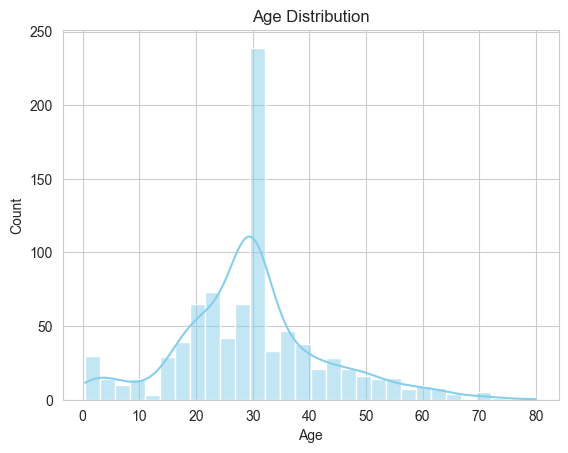

In [27]:
# 1. Phân phối tuổi (Age Distribution)
sns.histplot(df['Age'], bins = 30, kde = True, color = 'skyblue')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')

Text(0, 0.5, 'Count')

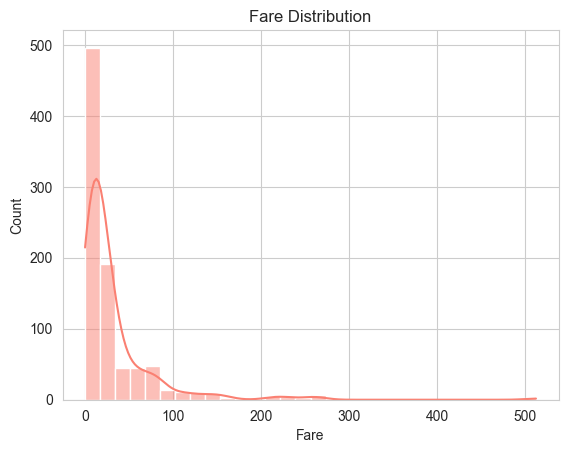

In [28]:
# 2. Phân phối giá vé (Fare Distribution)
sns.histplot(df['Fare'], bins = 30, kde = True, color = "salmon")
plt.title('Fare Distribution')
plt.xlabel('Fare')
plt.ylabel('Count')

Text(0, 0.5, 'Count')

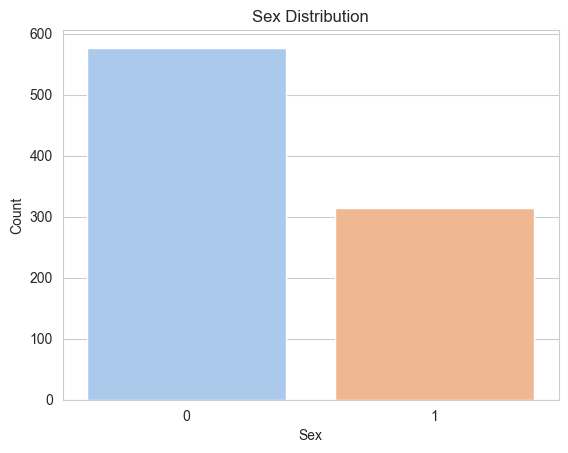

In [29]:
# 3. Phân phối giới tính (Sex Distribution)
sns.countplot(x ='Sex', data= df, palette= 'pastel')
plt.title('Sex Distribution')
plt.xlabel('Sex')
plt.ylabel('Count')

Text(0, 0.5, 'Count')

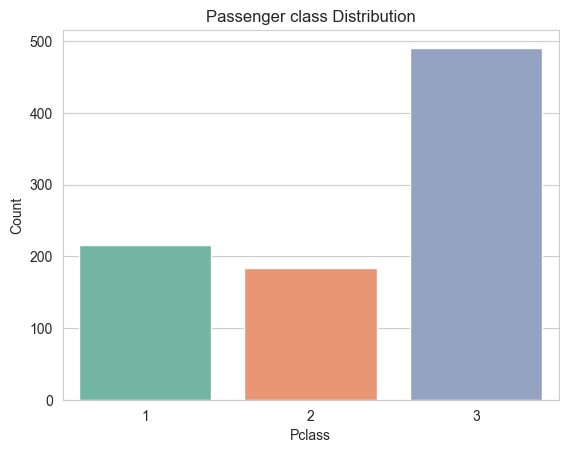

In [30]:
# 4. Phân phối hạng vé (Pclass Distribution)
sns.countplot(x = 'Pclass', data = df, palette= 'Set2')
plt.title('Passenger class Distribution')
plt.xlabel('Pclass')
plt.ylabel('Count')

### Gather Figure

Text(0, 0.5, 'Count')

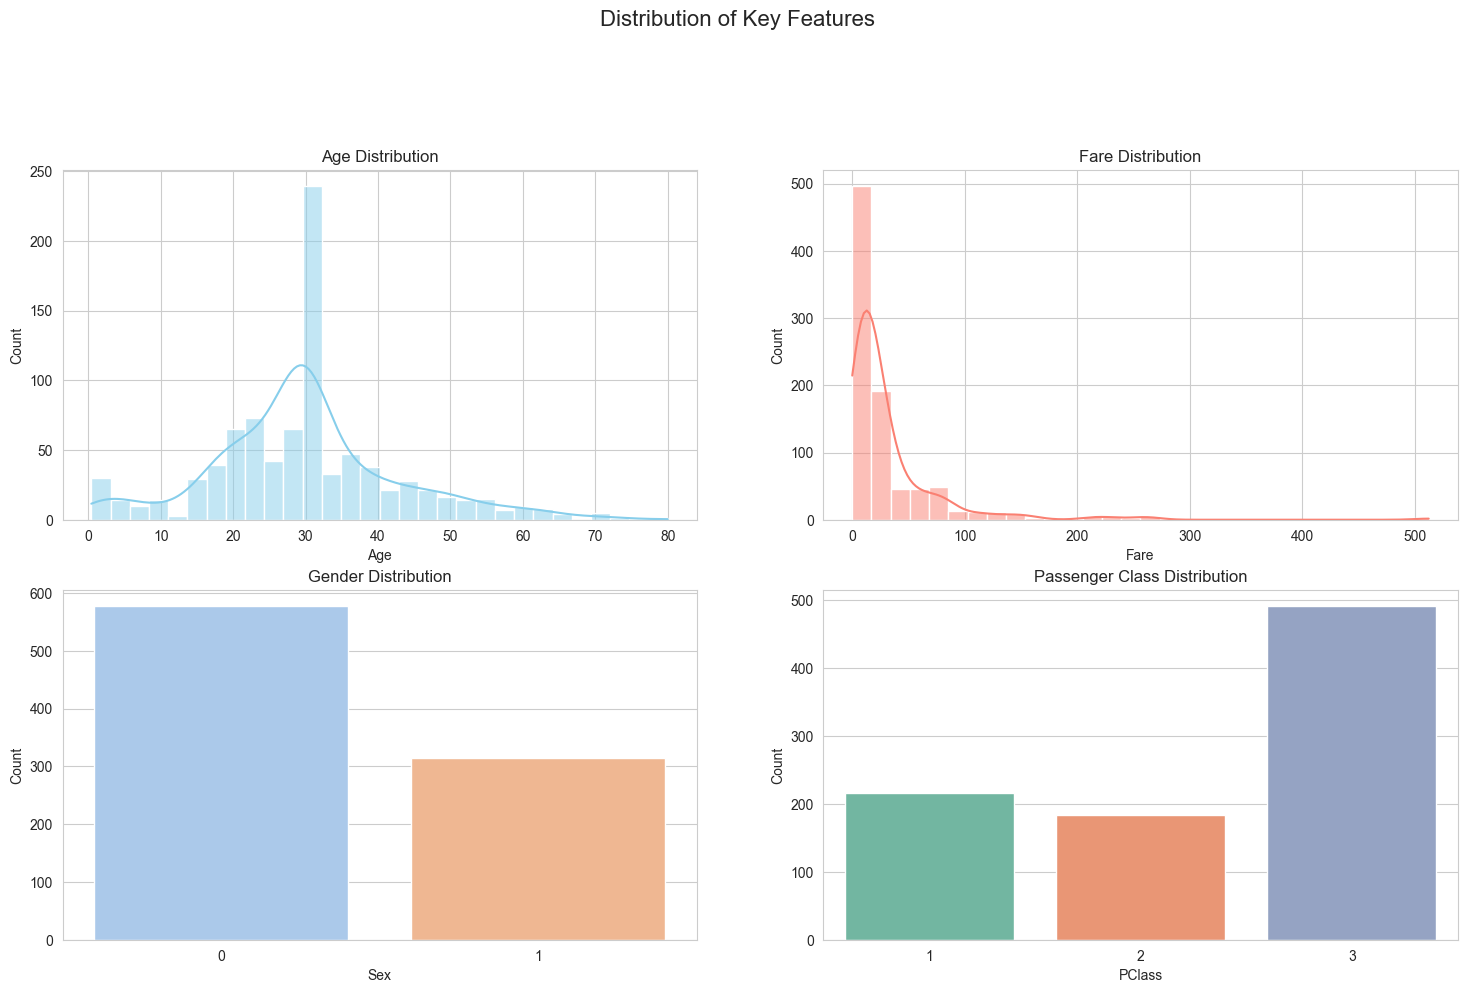

In [31]:
# Setup
plt.figure(figsize=(18, 10))
plt.suptitle("Distribution of Key Features", fontsize = 16, y = 1.04)

# 1. Phân phối tuổi (Age distribution)
plt.subplot(2, 2, 1)
sns.histplot(df['Age'], bins = 30, kde = True, color = 'skyblue')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')

# 2. Phân phối giá vé (Fare Distribution)
plt.subplot(2, 2, 2)
sns.histplot(df['Fare'], bins = 30, kde = True, color = "salmon")
plt.title('Fare Distribution')
plt.xlabel('Fare')
plt.ylabel('Count')

# 3. Phân phối giới tính (Sex Distribution)
plt.subplot(2, 2, 3)
sns.countplot(x = 'Sex', data = df, palette = 'pastel')
plt.title('Gender Distribution')
plt.xlabel('Sex')
plt.ylabel('Count')

# 4. Phân phối hạng vé (PClass Distribution)
plt.subplot(2, 2, 4)
sns.countplot(x = 'Pclass', data = df, palette = 'Set2')
plt.title('Passenger Class Distribution')
plt.xlabel('PClass')
plt.ylabel('Count')

## Survival Rate

In [32]:
df.columns

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'FamilySize', 'IsAlone', 'Title_Lady', 'Title_Master', 'Title_Miss',
       'Title_Mr', 'Title_Mrs', 'Title_Rare', 'Embarked_Q', 'Embarked_S',
       'AgeBin_Teen', 'AgeBin_Adult', 'AgeBin_Middle', 'AgeBin_Senior',
       'FareBin_Mid', 'FareBin_High', 'FareBin_Very High'],
      dtype='str')

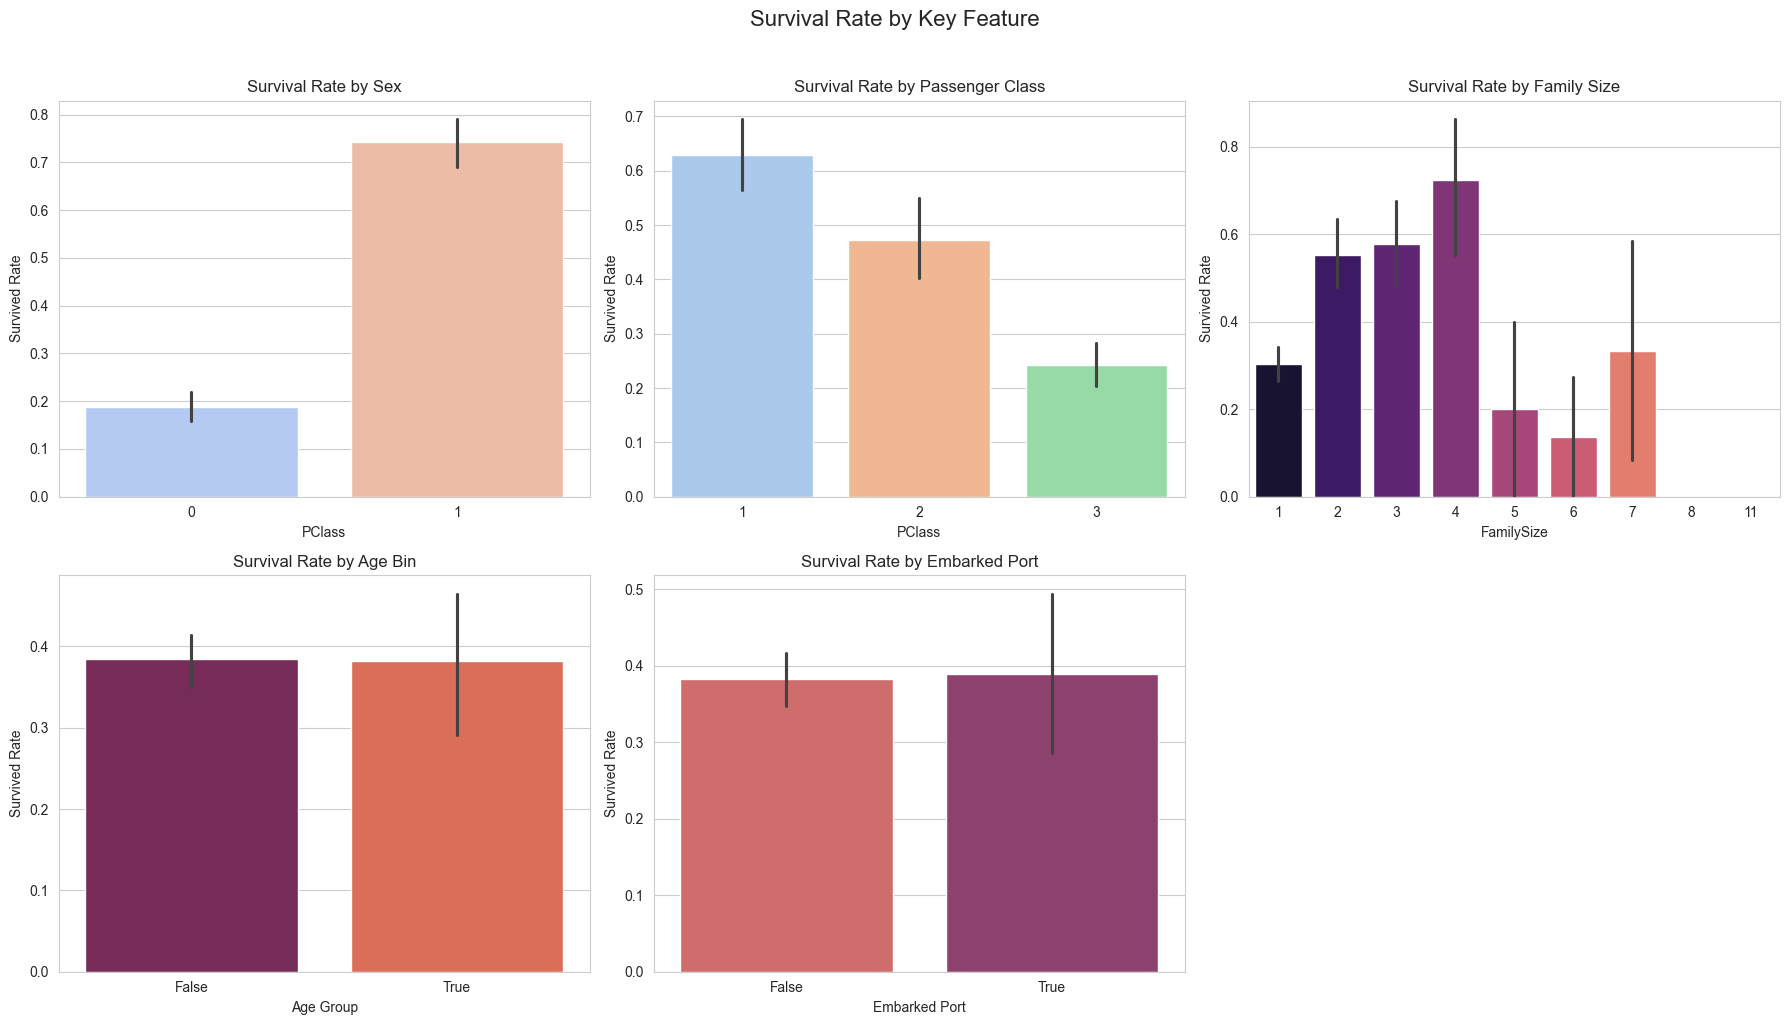

In [33]:
plt.figure(figsize=(18, 10))
plt.suptitle("Survival Rate by Key Feature", fontsize = 16, y = 1.02)

# 1. Tỷ lệ sống sót theo giới tính
plt.subplot(2, 3, 1)
sns.barplot(x = 'Sex', y = 'Survived', data = df, palette= 'coolwarm')
plt.title('Survival Rate by Sex')
plt.xlabel('PClass')
plt.ylabel('Survived Rate')

# 2. Tỷ lệ sống sót theo hạng vé
plt.subplot(2, 3, 2)
sns.barplot(x = 'Pclass', y='Survived', data = df, palette= 'pastel')
plt.title('Survival Rate by Passenger Class')
plt.xlabel('PClass')
plt.ylabel('Survived Rate')

# 3. Tỷ lệ sống sót theo số người thân đi cùng
plt.subplot(2, 3, 3)
sns.barplot(x = 'FamilySize', y = 'Survived', data = df, palette= 'magma')
plt.title('Survival Rate by Family Size')
plt.xlabel('FamilySize')
plt.ylabel('Survived Rate')

# 4. Tỷ lệ sống sót theo nhóm tuổi
plt.subplot(2, 3, 4)
sns.barplot(x = 'AgeBin_Teen', y = 'Survived', data = df, palette= 'rocket')
plt.title('Survival Rate by Age Bin')
plt.xlabel('Age Group')
plt.ylabel('Survived Rate')

# 5. Tỷ lệ sống sót theo cảng lên tàu
plt.subplot(2, 3, 5)
sns.barplot(x = 'Embarked_Q', y = 'Survived', data = df, palette= 'flare')
plt.title('Survival Rate by Embarked Port')
plt.xlabel('Embarked Port')
plt.ylabel('Survived Rate')


plt.tight_layout()
plt.show()



# Multivariate

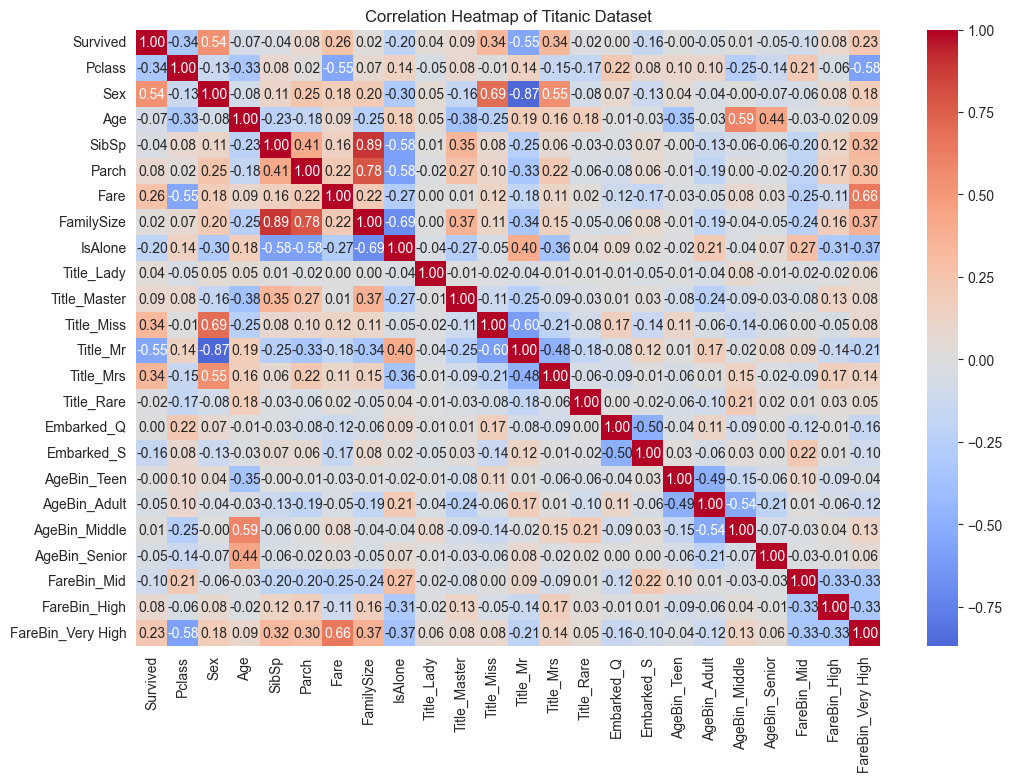

In [34]:
# 1. Heatmap tương quan giữa các biến
plt.figure(figsize= (12, 8))
corr = df.corr()
sns.heatmap(corr, annot = True, cmap = 'coolwarm', center = 0, fmt = '.2f')
plt.title('Correlation Heatmap of Titanic Dataset')
plt.show()


Text(0, 0.5, 'Fare')

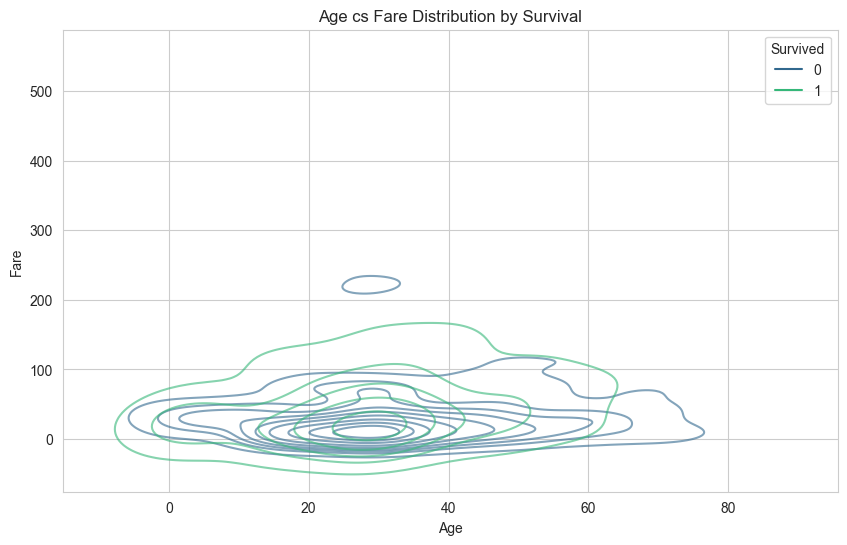

In [35]:
# 2. Phân phối Age và Fare theo Survival (KDR Plot)
plt.figure (figsize= (10, 6))
sns.kdeplot(data = df, x = 'Age', y = 'Fare',
            hue = 'Survived', palette= 'viridis', alpha = 0.6)
plt.title('Age cs Fare Distribution by Survival')
plt.xlabel('Age')
plt.ylabel('Fare')

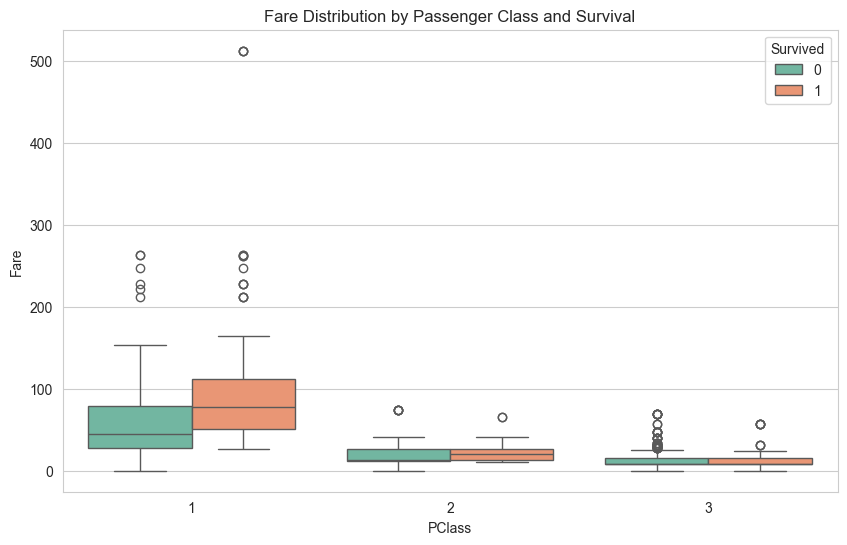

In [36]:
# 3. Boxplot Fare theo Pclass và Survival
plt.figure(figsize= (10, 6))
sns.boxplot(x = 'Pclass', y = 'Fare', hue = 'Survived', data = df, palette= 'Set2')
plt.title('Fare Distribution by Passenger Class and Survival')
plt.xlabel('PClass')
plt.ylabel('Fare')
plt.legend(title ='Survived', loc = 'upper right')
plt.show()

### Advanced

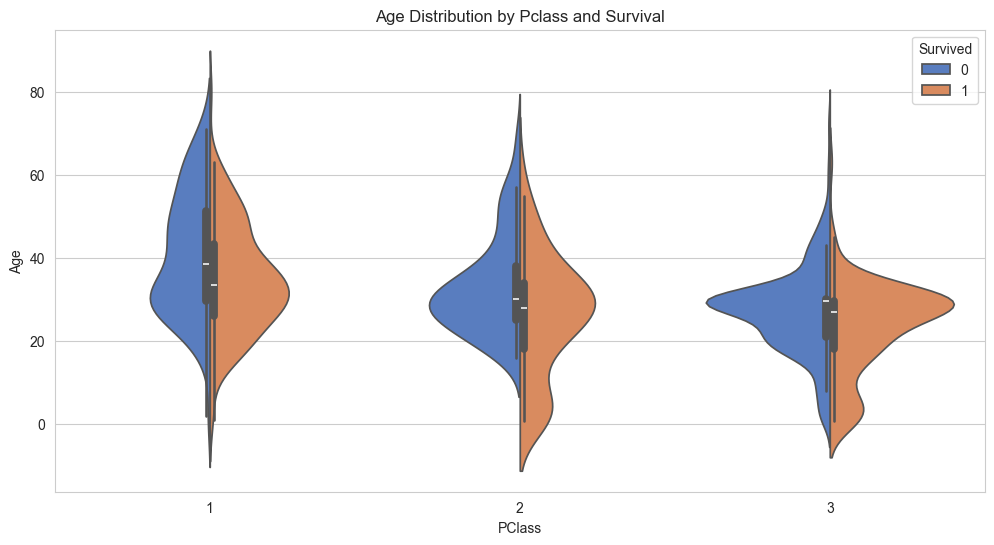

In [37]:
# 1. Violin Plot: Phân phối Age theo Pclass và Survival
plt.figure(figsize = (12, 6))
sns.violinplot(x = 'Pclass', y = 'Age', hue = 'Survived', data = df, split = True, palette= 'muted')
plt.title('Age Distribution by Pclass and Survival')
plt.xlabel('PClass')
plt.ylabel('Age')
plt.legend(title = 'Survived', loc = 'upper right')
plt.show()

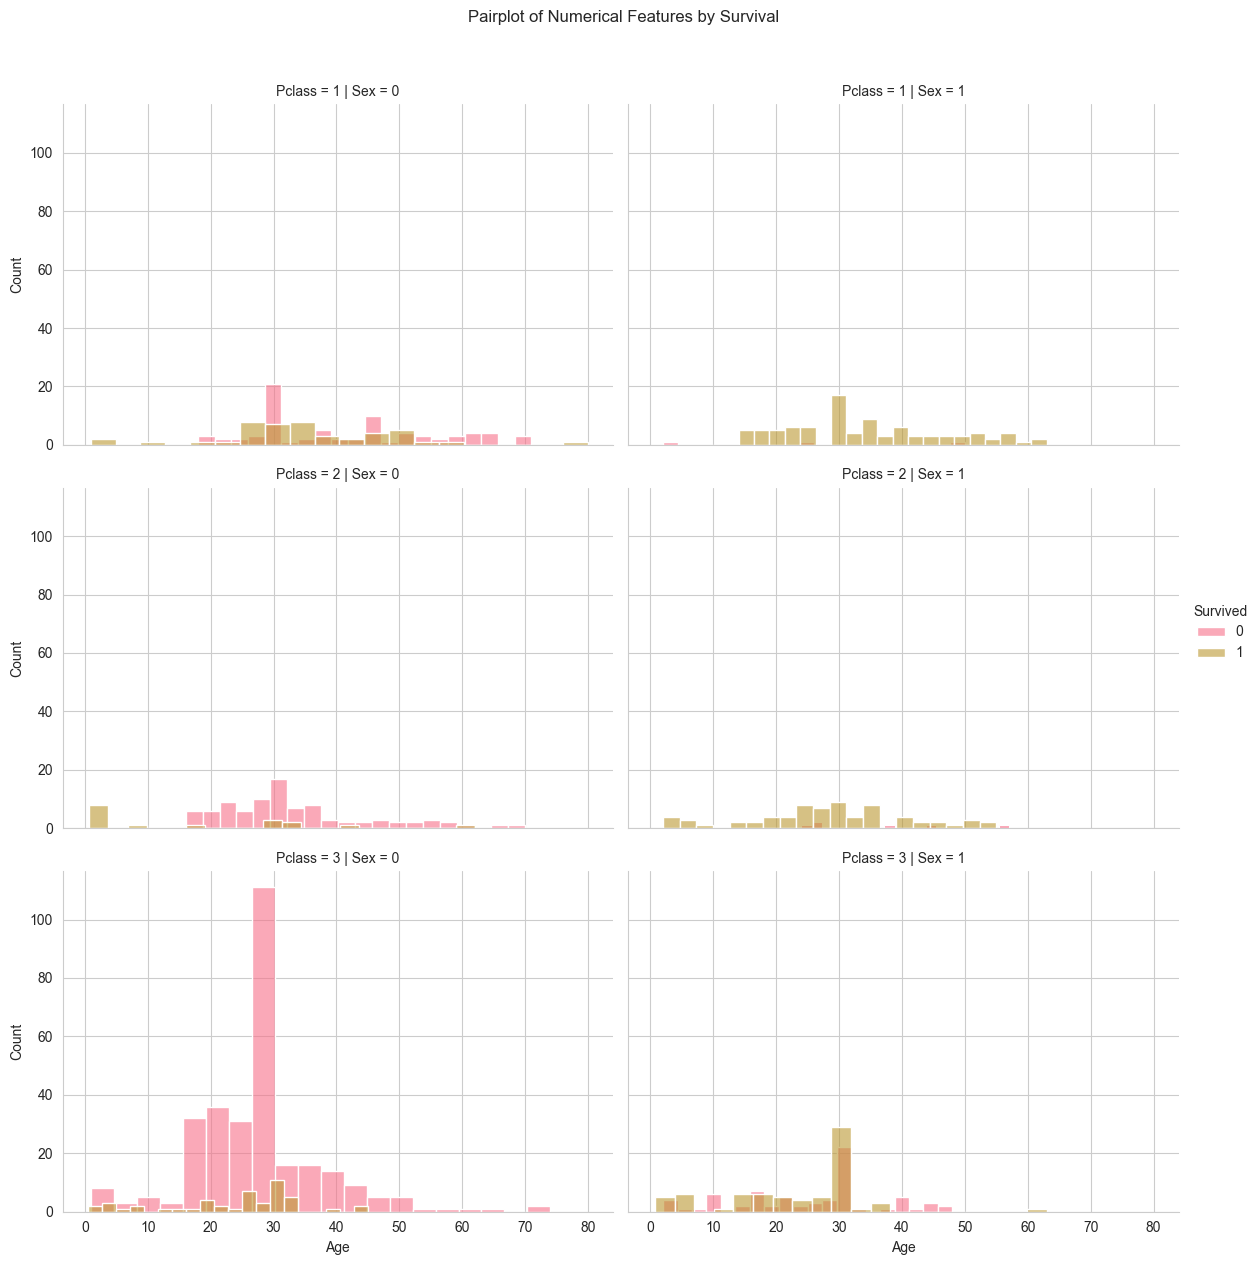

In [38]:
# 2. FacetGrid: Survival Rate theo Age và Sex
g = sns.FacetGrid(df, col = 'Sex', row = 'Pclass', hue='Survived', height = 4, aspect = 1.5)
g.map (sns.histplot, 'Age', alpha = 0.6, bins = 20)
g.add_legend()
plt.suptitle('Pairplot of Numerical Features by Survival', y = 1.05)
plt.show()

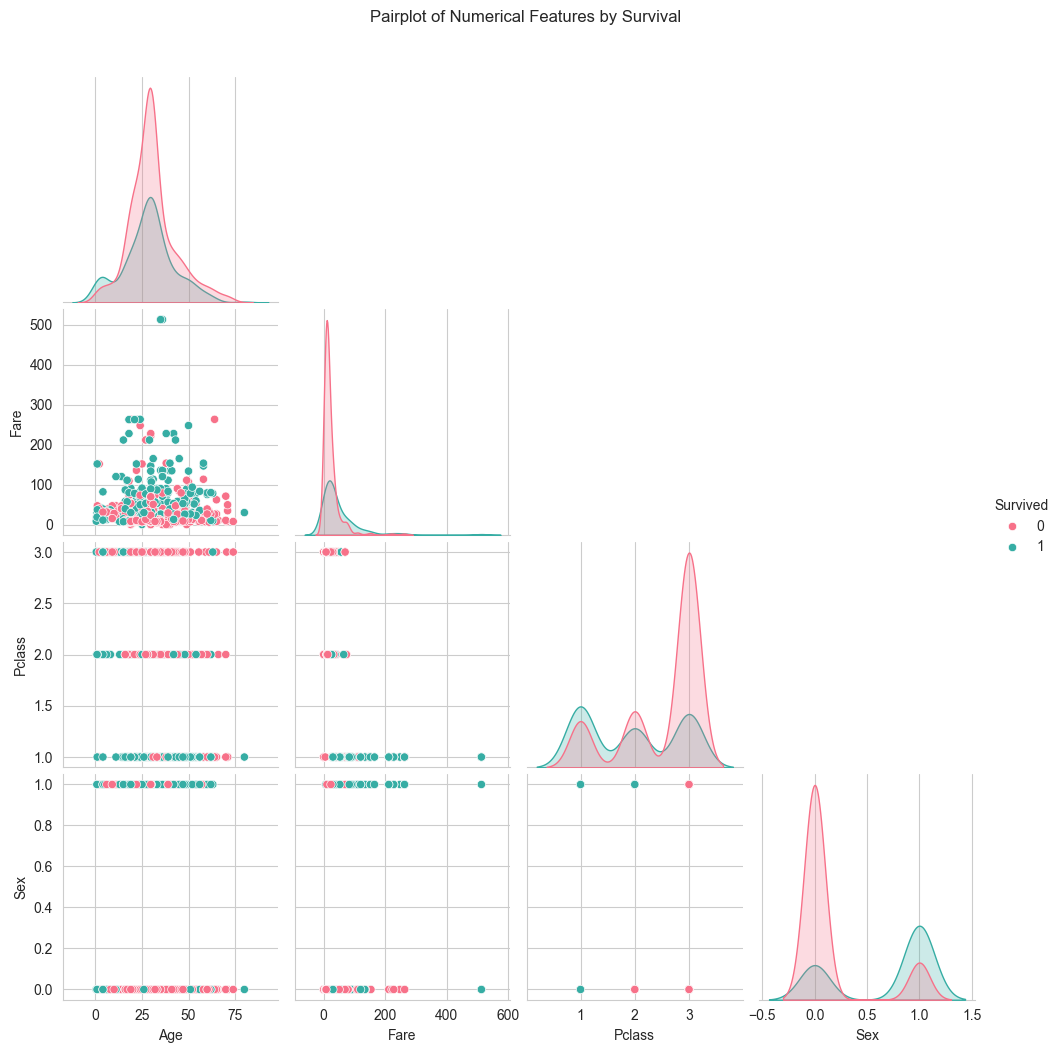

In [39]:
# 3. Pairplot của các biến số
sns.pairplot(df[['Age', 'Fare', 'Pclass', 'Survived', 'Sex']], hue ='Survived', corner= True, palette='husl')
plt.suptitle('Pairplot of Numerical Features by Survival', y= 1.05)
plt.show()